<a href="https://colab.research.google.com/github/Yahir-7/Data_Center_GeoPandas/blob/main/Drinkin_Water_Violations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

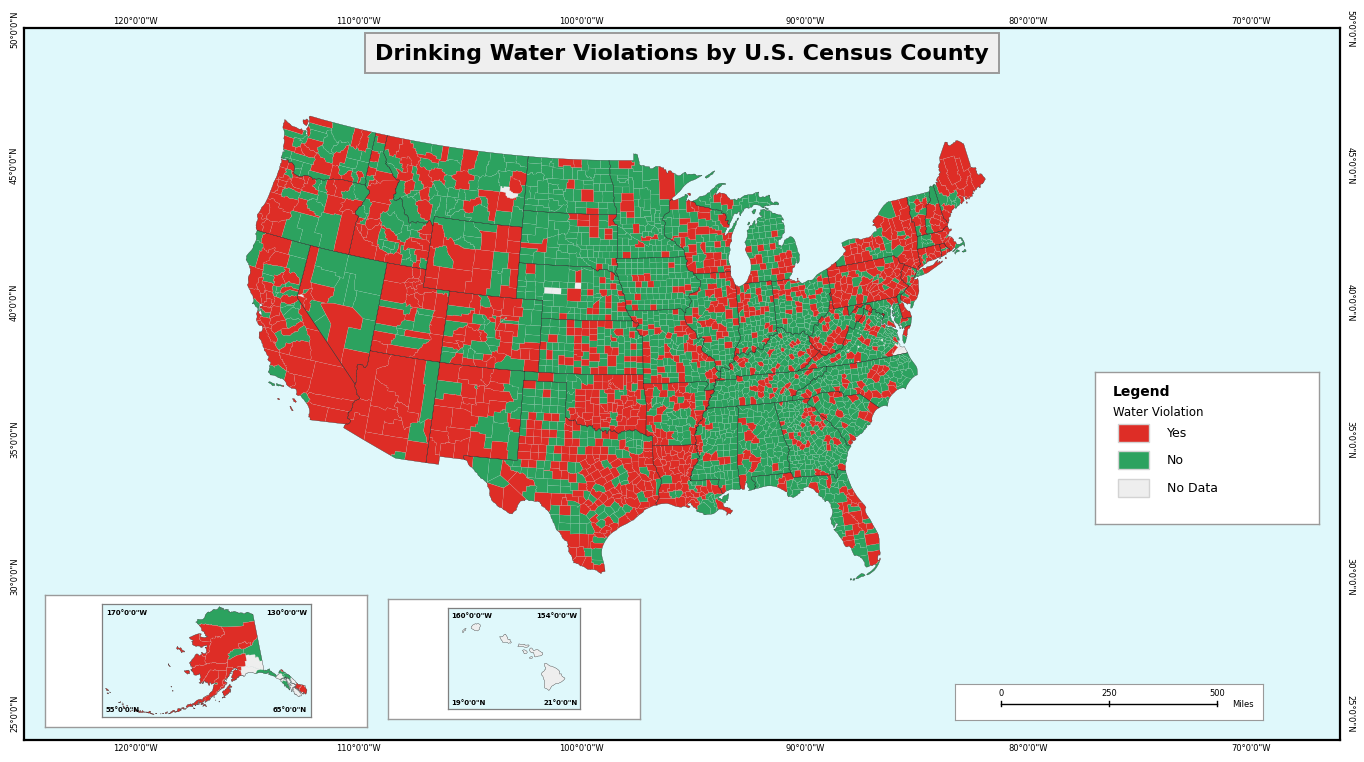

In [1]:
# Open In Colab

# Run Once
# ! pip install geopandas pandas matplotlib numpy openpyxl shapely

import numpy as np
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

file = "/content/2025 County Health Rankings Data - v4.xlsx"

# Load County Health Rankings data
excel_data = pd.read_excel(
    file,
    sheet_name="Select Measure Data",
    header=1
)

drinking_water = excel_data[[
    "FIPS",
    "State",
    "County",
    "Presence of Water Violation"
]].copy()

# Keep only county rows
drinking_water = drinking_water[drinking_water["County"].notna()].copy()

# Make FIPS match county shapefile GEOID
drinking_water["FIPS"] = (
    drinking_water["FIPS"]
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

# Clean violation values so they become Yes / No
raw_vals = drinking_water["Presence of Water Violation"]
numeric_vals = pd.to_numeric(raw_vals, errors="coerce")

drinking_water["water_violation_clean"] = pd.Series(index=drinking_water.index, dtype="object")

# Handle numeric values
drinking_water.loc[numeric_vals == 1, "water_violation_clean"] = "Yes"
drinking_water.loc[numeric_vals == 0, "water_violation_clean"] = "No"

# Handle text values
text_vals = raw_vals.astype(str).str.strip().str.lower()

drinking_water.loc[
    drinking_water["water_violation_clean"].isna() & text_vals.isin(["yes", "y", "true", "1.0"]),
    "water_violation_clean"
] = "Yes"

drinking_water.loc[
    drinking_water["water_violation_clean"].isna() & text_vals.isin(["no", "n", "false", "0.0"]),
    "water_violation_clean"
] = "No"

# Load county shapefile from U.S. Census Bureau
counties = gpd.read_file(
    "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip"
)

counties = counties.to_crs(epsg=4326)

# Merge county map with drinking water data
merged = counties.merge(
    drinking_water,
    left_on="GEOID",
    right_on="FIPS",
    how="left"
)

# Remove U.S. territories only
territory_codes = ["60", "66", "69", "72", "78"]
merged = merged[~merged["STATEFP"].isin(territory_codes)].copy()

# Split into maps
lower48 = merged[~merged["STATEFP"].isin(["02", "15"])].copy()
alaska = merged[merged["STATEFP"] == "02"].copy()
hawaii = merged[merged["STATEFP"] == "15"].copy()

# Projections
lower48_proj = lower48.to_crs(epsg=5070)
alaska_proj = alaska.to_crs(epsg=3338)
hawaii_proj = hawaii.to_crs(epsg=4326)

# Create state boundary layers
lower48_states = lower48_proj.dissolve(by="STATEFP")
alaska_states = alaska_proj.dissolve(by="STATEFP")
hawaii_states = hawaii_proj.dissolve(by="STATEFP")

# Colors
no_color = "#2ca25f"       # green
yes_color = "#de2d26"      # red
missing_color = "#eeeeee"  # light gray

# Plot each violation category safely
def plot_violation_map(ax, gdf, linewidth):
    missing = gdf[gdf["water_violation_clean"].isna()]
    no_df = gdf[gdf["water_violation_clean"] == "No"]
    yes_df = gdf[gdf["water_violation_clean"] == "Yes"]

    if not missing.empty:
        missing.plot(
            color=missing_color,
            edgecolor="lightgray",
            linewidth=linewidth,
            ax=ax,
            zorder=2
        )

    if not no_df.empty:
        no_df.plot(
            color=no_color,
            edgecolor="lightgray",
            linewidth=linewidth,
            ax=ax,
            zorder=3
        )

    if not yes_df.empty:
        yes_df.plot(
            color=yes_color,
            edgecolor="lightgray",
            linewidth=linewidth,
            ax=ax,
            zorder=3
        )

# Convert decimal degrees to degree-minute-second format
def decimal_to_dms(value, is_lon=True):
    if is_lon:
        direction = "W" if value < 0 else "E"
    else:
        direction = "S" if value < 0 else "N"

    value = abs(value)
    degrees = int(value)
    minutes_float = (value - degrees) * 60
    minutes = int(minutes_float)
    seconds = int(round((minutes_float - minutes) * 60))

    if seconds == 60:
        seconds = 0
        minutes += 1

    if minutes == 60:
        minutes = 0
        degrees += 1

    return f"{degrees}°{minutes}'{seconds}\"{direction}"

# Add DMS labels only, without grid lines
def add_dms_frame_labels(
    ax,
    lon_values,
    lat_values,
    lon_min,
    lon_max,
    lat_min,
    lat_max,
    lon_fontsize=6,
    lat_fontsize=6
):
    for lon in lon_values:
        x_frac = (lon - lon_min) / (lon_max - lon_min)
        label = decimal_to_dms(lon, is_lon=True)

        ax.text(
            x_frac,
            1.004,
            label,
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=lon_fontsize,
            color="black",
            clip_on=False
        )

        ax.text(
            x_frac,
            -0.004,
            label,
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=lon_fontsize,
            color="black",
            clip_on=False
        )

    for lat in lat_values:
        y_frac = (lat - lat_min) / (lat_max - lat_min)
        label = decimal_to_dms(lat, is_lon=False)

        ax.text(
            -0.004,
            y_frac,
            label,
            transform=ax.transAxes,
            ha="right",
            va="center",
            rotation=90,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False
        )

        ax.text(
            1.004,
            y_frac,
            label,
            transform=ax.transAxes,
            ha="left",
            va="center",
            rotation=270,
            fontsize=lat_fontsize,
            color="black",
            clip_on=False
        )

# Add coordinate labels directly on top of or below an inset map (inside the box)
def add_inset_edge_labels(ax, values, value_min, value_max, is_lon=True, fontsize=4.5, color="black", position="top"):
    n = len(values)
    y_pos = 0.96 if position == "top" else 0.04
    va = "top" if position == "top" else "bottom"

    for i, value in enumerate(values):
        x_frac = (value - value_min) / (value_max - value_min)
        label = decimal_to_dms(value, is_lon=is_lon)

        if i == 0:
            ha = "left"
            x_pos = 0.02
        elif i == n - 1:
            ha = "right"
            x_pos = 0.98
        else:
            ha = "center"
            x_pos = x_frac

        ax.text(
            x_pos,
            y_pos,
            label,
            transform=ax.transAxes,
            ha=ha,
            va=va,
            fontsize=fontsize,
            fontweight="bold",
            color=color,
            zorder=25
        )

# Draw a simple visual scale bar in its own small box
def draw_scale_box(ax, labels=("0", "250", "500"), unit="Miles"):
    ax.set_facecolor("white")

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
        spine.set_edgecolor("#9a9a9a")

    ax.set_xticks([])
    ax.set_yticks([])

    # Main scale line
    ax.plot([0.15, 0.85], [0.45, 0.45], color="black", linewidth=1.0)

    # Tick marks
    ax.plot([0.15, 0.15], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([0.50, 0.50], [0.38, 0.52], color="black", linewidth=1.0)
    ax.plot([0.85, 0.85], [0.38, 0.52], color="black", linewidth=1.0)

    # Labels
    ax.text(0.15, 0.62, labels[0], ha="center", va="bottom", fontsize=6)
    ax.text(0.50, 0.62, labels[1], ha="center", va="bottom", fontsize=6)
    ax.text(0.85, 0.62, labels[2], ha="center", va="bottom", fontsize=6)
    ax.text(0.90, 0.45, unit, ha="left", va="center", fontsize=6)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

# Figure layout
fig = plt.figure(figsize=(14, 8), facecolor="white")

# Background frame that fills the whole map layout
ax_frame_bg = fig.add_axes([0.025, 0.045, 0.94, 0.89], zorder=0)
ax_frame_bg.set_facecolor("#dff8fb")

for spine in ax_frame_bg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.2)
    spine.set_edgecolor("#7f7f7f")

ax_frame_bg.set_xticks([])
ax_frame_bg.set_yticks([])

# Main lower 48 map
ax_main = fig.add_axes([0.045, 0.210, 0.805, 0.650], zorder=2)
ax_main.set_facecolor("#dff8fb")

# Plot drinking water violation map
plot_violation_map(ax_main, lower48_proj, 0.08)

# Thin black state borders
lower48_states.boundary.plot(
    ax=ax_main,
    color="black",
    linewidth=0.18,
    zorder=4
)

# Keep main map centered and fitted
minx, miny, maxx, maxy = lower48_proj.total_bounds
x_buffer = (maxx - minx) * 0.030
y_buffer = (maxy - miny) * 0.060

ax_main.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_main.set_ylim(miny - y_buffer, maxy + y_buffer)

# Remove the inner main-map border so only the big outer border shows
for spine in ax_main.spines.values():
    spine.set_visible(False)

ax_main.set_xticks([])
ax_main.set_yticks([])

# Alaska outer white box
ak_outer = fig.add_axes([0.040, 0.062, 0.230, 0.165], zorder=4)
ak_outer.set_facecolor("white")

for spine in ak_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ak_outer.set_xticks([])
ak_outer.set_yticks([])

# Alaska inner map box
ak_inner_left = 0.020
ak_inner_bottom = 0.075
ak_inner_width = 0.960
ak_inner_height = 0.850

ax_ak = ak_outer.inset_axes([
    ak_inner_left,
    ak_inner_bottom,
    ak_inner_width,
    ak_inner_height
])

ax_ak.set_facecolor("#dff8fb")

plot_violation_map(ax_ak, alaska_proj, 0.10)

alaska_states.boundary.plot(
    ax=ax_ak,
    color="black",
    linewidth=0.20,
    zorder=4
)

minx, miny, maxx, maxy = alaska_proj.total_bounds
x_buffer = (maxx - minx) * 0.02
y_buffer = (maxy - miny) * 0.02

ax_ak.set_xlim(minx - x_buffer, maxx + x_buffer)
ax_ak.set_ylim(miny - y_buffer, maxy + y_buffer)

for spine in ax_ak.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_ak.set_xticks([])
ax_ak.set_yticks([])

# Alaska longitude labels, overlaid on top of the map
add_inset_edge_labels(
    ax=ax_ak,
    values=[-170, -130],
    value_min=-180,
    value_max=-130,
    is_lon=True,
    fontsize=5,
    position="top"
)

# Alaska latitude labels, overlaid on the bottom of the map
add_inset_edge_labels(
    ax=ax_ak,
    values=[55, 65],
    value_min=50,
    value_max=72,
    is_lon=False,
    fontsize=5,
    position="bottom"
)

# Hawaii outer white box
hi_outer = fig.add_axes([0.285, 0.072, 0.180, 0.150], zorder=4)
hi_outer.set_facecolor("white")

for spine in hi_outer.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

hi_outer.set_xticks([])
hi_outer.set_yticks([])

# Hawaii inner map box
hi_inner_left = 0.025
hi_inner_bottom = 0.080
hi_inner_width = 0.950
hi_inner_height = 0.840

ax_hi = hi_outer.inset_axes([
    hi_inner_left,
    hi_inner_bottom,
    hi_inner_width,
    hi_inner_height
])

ax_hi.set_facecolor("#dff8fb")

plot_violation_map(ax_hi, hawaii_proj, 0.10)

hawaii_states.boundary.plot(
    ax=ax_hi,
    color="black",
    linewidth=0.20,
    zorder=4
)

ax_hi.set_xlim(-161, -154)
ax_hi.set_ylim(18, 23)

for spine in ax_hi.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.9)
    spine.set_edgecolor("#7f7f7f")

ax_hi.set_xticks([])
ax_hi.set_yticks([])

# Hawaii longitude labels, overlaid on top of the map
add_inset_edge_labels(
    ax=ax_hi,
    values=[-160, -154],
    value_min=-161,
    value_max=-154,
    is_lon=True,
    fontsize=5,
    position="top"
)

# Hawaii latitude labels, overlaid on the bottom of the map
add_inset_edge_labels(
    ax=ax_hi,
    values=[19, 21],
    value_min=18,
    value_max=23,
    is_lon=False,
    fontsize=5,
    position="bottom"
)

# Main scale bar in bottom-right corner
ax_scale = fig.add_axes([0.690, 0.070, 0.220, 0.045], zorder=4)
draw_scale_box(ax_scale, labels=("0", "250", "500"), unit="Miles")

# Legend box
ax_leg = fig.add_axes([0.790, 0.315, 0.160, 0.190], zorder=4)
ax_leg.set_facecolor("white")

for spine in ax_leg.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.0)
    spine.set_edgecolor("#9a9a9a")

ax_leg.set_xticks([])
ax_leg.set_yticks([])

# Legend title
ax_leg.text(
    0.08,
    0.92,
    "Legend",
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="top"
)

ax_leg.text(
    0.08,
    0.78,
    "Water Violation",
    fontsize=8.5,
    ha="left",
    va="top"
)

# Legend color swatches (categorical, like Yes / No / No Data)
legend_items = [
    ("Yes", yes_color),
    ("No", no_color),
    ("No Data", missing_color)
]

y_positions = [0.60, 0.42, 0.24]

for (label, color), y in zip(legend_items, y_positions):
    ax_leg.add_patch(
        plt.Rectangle(
            (0.10, y - 0.06),
            0.14,
            0.12,
            facecolor=color,
            edgecolor="lightgray",
            transform=ax_leg.transAxes
        )
    )

    ax_leg.text(
        0.32,
        y,
        label,
        fontsize=9,
        ha="left",
        va="center"
    )

# Transparent top frame for border, coordinate labels, and title
ax_frame = fig.add_axes([0.025, 0.045, 0.94, 0.89], zorder=10)
ax_frame.patch.set_alpha(0)

for spine in ax_frame.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(1.6)
    spine.set_edgecolor("black")

ax_frame.set_xticks([])
ax_frame.set_yticks([])

# DMS coordinate labels around the whole map layout
add_dms_frame_labels(
    ax=ax_frame,
    lon_values=[-120, -110, -100, -90, -80, -70],
    lat_values=[25, 30, 35, 40, 45, 50],
    lon_min=-125,
    lon_max=-66,
    lat_min=24,
    lat_max=50,
    lon_fontsize=6,
    lat_fontsize=6
)

# Title inside the big frame
ax_frame.text(
    0.5,
    0.965,
    "Drinking Water Violations by U.S. Census County",
    transform=ax_frame.transAxes,
    ha="center",
    va="center",
    fontsize=16,
    fontweight="bold",
    bbox=dict(
        facecolor="#efefef",
        edgecolor="#9a9a9a",
        boxstyle="square,pad=0.45",
        linewidth=1.4
    ),
    zorder=20
)

plt.show()